In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
#combining main csv dataset with supplementary temperature data csv
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

#limiting dataset to just time interval of interest
pa_gs = pa_gs[pa_gs['year'] >= 1960]
#dropping non-numeric columns
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_unstandardized(data, target_var_name, cov_list):

    # takes in dataframe, desired target variable, and a list of covariates to be included in addition to time ("year") 
    # in an unstandardized bayesian heteroskedastic regression model.
    # outputs the model data tree, output data tree, and model residuals.
    
    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data = remove_nulls_simple(data, cov_list_target_var)
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid

In [4]:
cov_list_all = ['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
cov_str_all = list_to_str(cov_list_all)

In [6]:
interaction_list_all = ['latitude','longitude','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
interaction_str_all = list_to_str(interaction_list_all)
formula_interaction = bmb.Formula(f"growing_season_length ~ dtr_annual*tmean_spring + {interaction_str_all} + year",
                      f"sigma ~ dtr_annual*tmean_spring + {interaction_str_all} + year")
model_interaction = bmb.Model(formula_interaction, data=pa_gs, dropna = True)
output_interaction = model_interaction.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.100       63          66.21 draws/s        0:00:30    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.109       31          80.00 draws/s        0:00:24    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.086       31          90.37 draws/s        0:00:22    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.090       31          84.84 draws/s        0:00:23    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.


In [7]:
az.summary(output_interaction)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,440,70,320,550,3927,3287,1.00,1.1,0.78
dtr_annual,-4.22,0.79,-5.5,-3,2909,2791,1.00,0.015,0.01
tmean_spring,10.96,0.94,9.5,12,2782,2762,1.00,0.018,0.013
dtr_annual:tmean_spring,-0.517,0.081,-0.65,-0.39,2814,2506,1.00,0.0015,0.0011
latitude,-4.22,0.66,-5.3,-3.1,4194,3470,1.00,0.01,0.0071
longitude,1.732,0.225,1.4,2.1,3883,3153,1.00,0.0036,0.0025
oni_annual,-3.13,0.51,-3.9,-2.3,4693,3426,1.00,0.0074,0.005
nao_annual,1.71,0.9,0.28,3.1,4588,2909,1.00,0.013,0.0095
pna_annual,5.35,0.99,3.8,6.9,5617,3286,1.00,0.013,0.0095
amo_annual,0.9,3.68,-5.2,6.7,4032,3244,1.00,0.058,0.041


In [63]:
interaction_2_list_all = ['latitude','longitude','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico']
interaction_2_str_all = list_to_str(interaction_2_list_all)
formula_interaction_2 = bmb.Formula(f"growing_season_length ~ dtr_annual*tmean_fall + {interaction_2_str_all} + year",
                      f"sigma ~ dtr_annual*tmean_fall + {interaction_2_str_all} + year")
model_interaction_2 = bmb.Model(formula_interaction_2, data=pa_gs, dropna = True)
output_interaction_2 = model_interaction_2.fit()

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.121       31          95.37 draws/s        0:00:20    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.081       31          76.40 draws/s        0:00:26    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.113       31          100.10 draws/s       0:00:19    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.124       63          77.54 draws/s        0:00:25    0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


In [64]:
az.summary(output_interaction_2)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,24,55,-64,110,3919,3739,1.00,0.87,0.61
dtr_annual,-1.88,0.96,-3.4,-0.33,2005,1770,1.00,0.021,0.016
tmean_fall,13.95,0.93,12,15,2027,1937,1.00,0.021,0.015
dtr_annual:tmean_fall,-0.529,0.082,-0.66,-0.4,2014,1885,1.00,0.0018,0.0014
latitude,-4.56,0.55,-5.4,-3.7,3879,3429,1.00,0.0089,0.0062
longitude,1.222,0.199,0.91,1.5,3666,3239,1.00,0.0033,0.0024
oni_annual,-0.14,0.414,-0.8,0.52,4162,2885,1.00,0.0064,0.0047
nao_annual,-1.07,0.74,-2.2,0.14,4247,3020,1.00,0.011,0.0078
pna_annual,0.03,0.85,-1.3,1.4,4340,3307,1.00,0.013,0.0089
amo_annual,8.5,3.63,2.6,14,3084,2561,1.00,0.066,0.048


In [48]:
dtrv_by_year = pa_gs.groupby('year')['dtr_annual'].var()
dtrv_by_year = dtrv_by_year.reset_index()
dtrv_70_99 = dtrv_by_year[dtrv_by_year['year'].between(1970,1999)]
dtrv_99_25 = dtrv_by_year[dtrv_by_year['year'].between(1999,2025)]

In [49]:
dtrv_70_99_X = dtrv_70_99['year']
dtrv_70_99_y = dtrv_70_99['dtr_annual']
dtrv_70_99_X = sm.add_constant(dtrv_70_99_X)
dtrv_99_25_X = dtrv_99_25['year']
dtrv_99_25_y = dtrv_99_25['dtr_annual']
dtrv_99_25_X = sm.add_constant(dtrv_99_25_X)

In [50]:
dtrv_70_99_mod = sm.OLS(dtrv_70_99_y, dtrv_70_99_X).fit()
dtrv_99_25_mod = sm.OLS(dtrv_99_25_y, dtrv_99_25_X).fit()

In [51]:
print(dtrv_70_99_mod.summary())
print(dtrv_99_25_mod.summary())

                            OLS Regression Results                            
Dep. Variable:             dtr_annual   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     21.40
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           7.71e-05
Time:                        10:11:14   Log-Likelihood:                -2.2079
No. Observations:                  30   AIC:                             8.416
Df Residuals:                      28   BIC:                             11.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -50.1814     11.285     -4.447      0.0

In [57]:
print("1970 - 2000")
print("Slope:", dtrv_70_99_mod.params.values[1])
print(dtrv_70_99[dtrv_70_99['year']==1970]['dtr_annual'])
print("1999 - 2025")
print("Slope:", dtrv_99_25_mod.params.values[1])
print(dtrv_99_25[dtrv_99_25['year']==2001]['dtr_annual'])

1970 - 2000
Slope: 0.02630673121121385
10    1.72643
Name: dtr_annual, dtype: float64
1999 - 2025
Slope: -0.04536144984895733
41    1.838669
Name: dtr_annual, dtype: float64


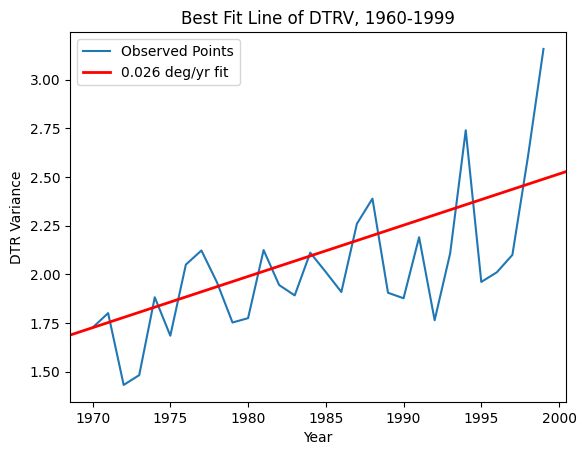

In [60]:
plt.plot(dtrv_70_99['year'], dtrv_70_99['dtr_annual'], label = 'Observed Points')
plt.axline((1970, 1.7263), slope = 0.0263067, linewidth = 2, color = 'r', label = '0.026 deg/yr fit')

plt.xlabel('Year')
plt.ylabel('DTR Variance')
plt.title('Best Fit Line of DTRV, 1960-1999')
plt.legend()
plt.show()

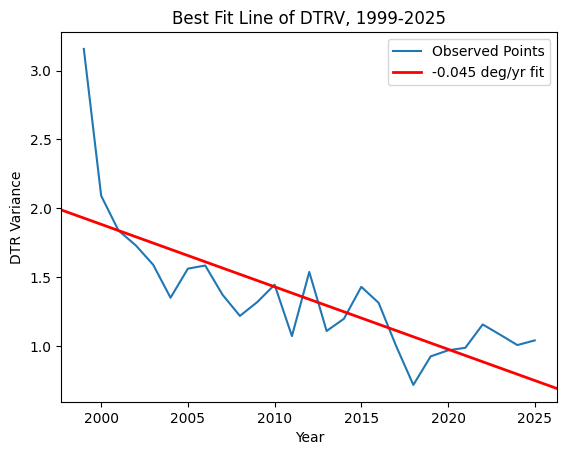

In [61]:
plt.plot(dtrv_99_25['year'], dtrv_99_25['dtr_annual'], label = 'Observed Points')
plt.axline((2001, 1.838669), slope = -0.04536145, linewidth = 2, color = 'r', label = '-0.045 deg/yr fit')

plt.xlabel('Year')
plt.ylabel('DTR Variance')
plt.title('Best Fit Line of DTRV, 1999-2025')
plt.legend()
plt.show()